<a href="https://colab.research.google.com/github/younso-sys/projet-younso/blob/main/Formation_Python_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# La programmation avec Python & la Pensée Computationnelle
**Collège Doctoral de l'Université de Montpellier & Pythagore-Éducation**
Formation doctorale intensive (7 heures) • 09h00 – 17h00

## Module 1 : Introduction et « Mise en Corps » de l'Algorithme (09h00 – 10h00)
* **Silent Sorting :** Ordre séquentiel et différence entre sémantique (intention) et syntaxe (instruction atomique).
* **Modèle de communication :** Émetteur (Chercheur) -> Message (Code) -> Récepteur (Python) -> Bruit (`SyntaxError`).

In [ ]:
# Module 1 : Premier test d'exécution
message = 'Bonjour, bienvenue au Collège Doctoral !'
print(message)

Bonjour, bienvenue au Collège Doctoral !


## Module 2 : Syntaxe Python et Contrôle du Flux (10h00 – 11h15)
### 2.1 Variables et typage dynamique
Une variable est une boîte étiquetée. L'affectation `=` se lit de droite à gauche.

In [ ]:
nb_echantillons = 42          # int (comptage discret)
temperature_cuve = 37.2       # float (mesure continue)
statut_groupe = 'Placebo'     # str (métadonnée textuelle)
test_valide = True            # bool

print('Type de nb_echantillons :', type(nb_echantillons))
print('Type de temperature_cuve :', type(temperature_cuve))

Type de nb_echantillons : <class 'int'>
Type de temperature_cuve : <class 'float'>


### 2.2 Conditions (if/elif/else) et indentation obligatoire

In [ ]:
p_valeur = 0.024
seuil_alpha = 0.05

if p_valeur < 0.001:
    print('Résultat hautement significatif (***)')
elif p_valeur < seuil_alpha:
    print('Résultat significatif (*)')
else:
    print('Absence d\'effet détecté (ns)')

### 2.3 Boucle for et exercice de traitement de texte

In [ ]:
mots_resume = ['cette', 'etude', 'analyse', 'la', 'cellule', 'cancereuse',
               'chaque', 'cellule', 'repond', 'au', 'traitement']
cible = 'cellule'
compteur = 0

for mot in mots_resume:
    if mot == cible:
        compteur += 1

print(f"Le mot '{cible}' apparaît {compteur} fois.")

Le mot 'cellule' apparaît 2 fois.


## Module 3 : Structures de Données et Science Ouverte (11h30 – 12h30)
* **Listes `[]` :** Mutables (modifiables avec `.append()`).
* **Tuples `()` :** Immuables (sécurité pour constantes ou coordonnées GPS).
* **Dictionnaires `{}` :** Clé -> Valeur, indispensable pour les métadonnées et données FAIR (DMP).

In [ ]:
# Dictionnaire d'échantillon auto-documenté (format standard FAIR/JSON)
echantillon = {
    'code_tube': 'ECH_2026_09',
    'type_tissu': 'Biopsie',
    'ph': 7.35,
    'temperature_stockage': -80.0,
    'replicats': [12.4, 12.8, 12.1]
}

print('Code :', echantillon['code_tube'])
print('Moyenne réplicats :', sum(echantillon['replicats']) / len(echantillon['replicats']))

Code : ECH_2026_09
Moyenne réplicats : 12.433333333333332


### Atelier : Le Nettoyeur de Données

In [ ]:
donnees_brutes = ['12.4', '  15.1  ', 'ERROR', '18.3', 'NA', 'corrompu', '14.2']
donnees_propres = []

for element in donnees_brutes:
    if element not in ['ERROR', 'NA', 'corrompu']:
        valeur = float(element.strip())
        donnees_propres.append(valeur)

print('Données normalisées :', donnees_propres)
print('Moyenne fiable :', round(sum(donnees_propres) / len(donnees_propres), 2))

## Module 4 : Fonctions et Modularité (13h30 – 14h45)
* **Analogie managériale :** Une fonction est un stagiaire spécialisé.
* **Paramètres :** La consigne et les documents confiés.
* **Encapsulation :** Le travail dans son bureau (portée locale des variables).
* **`return` :** Le livrable posé sur votre table (contrairement à `print` qui ne fait que crier la valeur).

In [ ]:
def standardiser_zscore(valeur, moyenne, ecart_type):
    """Calcule le Z-score avec protection contre la division par zéro."""
    if ecart_type == 0:
        return 0.0
    z = (valeur - moyenne) / ecart_type
    return round(z, 3)

def taux_gc(sequence_adn):
    """Calcule le pourcentage de G+C dans un brin d'ADN."""
    seq = sequence_adn.upper().strip()
    nb_gc = seq.count('G') + seq.count('C')
    return round((nb_gc / len(seq)) * 100, 2)

print('Z-score calculé :', standardiser_zscore(18.4, 15.0, 2.1))
print('Taux GC ADN :', taux_gc('ATGCGATCGATCGATC'), '%')

## Module 5 : Initiation à la Programmation Orientée Objet (15h00 – 16h15)
* **Classe :** Le plan d'architecte abstrait (unique).
* **Objet (Instance) :** L'immeuble réel vivant en mémoire.
* **`self` :** Représente l'objet lui-même (« mon attribut à moi »).
* **Activité Embodied Objects :** Modélisation de la classe `Chercheur`.

In [ ]:
class Chercheur:
    def __init__(self, nom, discipline):
        self.nom = nom
        self.discipline = discipline
        self.h_index = 1
        self.energie = 100

    def publier(self):
        self.h_index += 1
        self.energie -= 10
        print(f'{self.nom} publie un article ! (h-index: {self.h_index})')

    def collaborer(self, confrere):
        self.h_index += 1
        confrere.h_index += 1
        self.energie -= 15
        confrere.energie -= 15
        print(f'Collaboration entre {self.nom} et {confrere.nom} !')

# Instanciation et interaction en mémoire
chercheur_1 = Chercheur('Alice', 'Génétique')
chercheur_2 = Chercheur('Bob', 'Informatique')

chercheur_1.publier()
chercheur_1.collaborer(chercheur_2)
print(f'{chercheur_1.nom} : h-index={chercheur_1.h_index}, énergie={chercheur_1.energie}%')
print(f'{chercheur_2.nom} : h-index={chercheur_2.h_index}, énergie={chercheur_2.energie}%')

## Module 6 : Projet Intégrateur & Code Review (16h15 – 17h00)
Le Défi Final : Création d'une classe `Reference` et d'un moteur de recherche d'articles pour la thèse.

In [ ]:
class Reference:
    def __init__(self, titre, auteur, annee, revue, doi=''):
        self.titre = titre
        self.auteur = auteur
        self.annee = int(annee)
        self.revue = revue
        self.doi = doi

    def formater_apa(self):
        texte = f'{self.auteur} ({self.annee}). {self.titre}. {self.revue}.'
        if self.doi:
            texte += f' DOI: {self.doi}'
        return texte

def chercher_par_motcle(bibliotheque, mot_cle):
    resultats = []
    terme = mot_cle.lower().strip()
    for ref in bibliotheque:
        if (terme in ref.titre.lower()) or (terme in ref.auteur.lower()):
            resultats.append(ref)
    return resultats

# Base de données de thèse
biblio_these = [
    Reference('Genome editing with CRISPR-Cas9', 'Charpentier E.', 2020, 'Nature', '10.1038/nature123'),
    Reference('Machine learning in clinical oncology', 'Dupont A.', 2024, 'Lancet', '10.1016/lancet456'),
    Reference('Deep learning methods for biology', 'Martin B.', 2025, 'Science', '10.1126/science789')
]

# Recherche
resultats = chercher_par_motcle(biblio_these, 'learning')
print(f"=== Résultats trouvés ({len(resultats)}) ===")
for r in resultats:
    print('->', r.formater_apa())





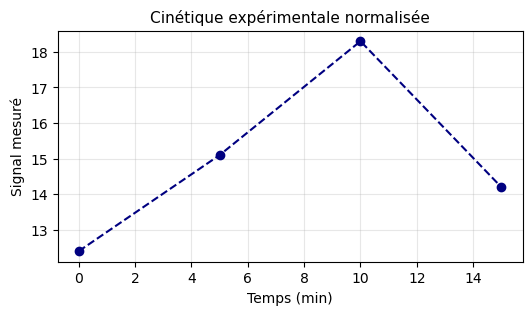

In [ ]:
# --- BONUS VISUALISATION : 4 lignes pour tracer les données du Module 3 ---
import matplotlib.pyplot as plt

# Reprise des données nettoyées du Module 3
mesures_propres = [12.4, 15.1, 18.3, 14.2]
temps_minutes = [0, 5, 10, 15]

# Tracé immédiat
plt.figure(figsize=(6, 3))
plt.plot(temps_minutes, mesures_propres, marker='o', color='navy', linestyle='--')
plt.title("Cinétique expérimentale normalisée", fontsize=11)
plt.xlabel("Temps (min)")
plt.ylabel("Signal mesuré")
plt.grid(True, alpha=0.3)

# Affichage dans Jupyter
plt.show()